In [1]:
import matplotlib.pyplot as plt
from itertools import product
from qaoa_parameter_setting.utils.labels import format_method_label_to
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle, Patch

# Example styling for Parameter Setting Paper

- Styling dictionaries, appropriate for `**kwargs` usage in `plt.scatter` and `plt.plot`, are provided by `style_scatter()` and `style_plot()`.
- The cell below defines some good matplotlib rcparams settings, such as using LaTeX for text rendering and setting font sizes.
- The `figsize()` function computes the figure size based on the number of columns and the aspect ratio of the figure.
- The `format_method_label_to()` function from `qaoa_parameter_settings.utils.labels` formats method label superscript markers using LaTeX. For example, `"*"` is mapped to `"$\star$"`.

This notebook also includes example code to create a legend with the appropriate entries. Adjust as needed.

In [2]:
# Configure matplotlib to use LaTeX for text rendering and set font sizes
plt.rcParams["text.usetex"] = True
plt.rcParams["legend.fontsize"] = "small"
plt.rcParams["legend.columnspacing"] = 1
plt.rcParams["axes.titlesize"] = "small"
plt.rcParams["axes.labelsize"] = "small"
plt.rcParams["figure.labelsize"] = "small"
plt.rcParams["xtick.labelsize"] = "small"
plt.rcParams["ytick.labelsize"] = "small"


In [3]:
# We use Paul Tol's bright colour scheme
# Define color mapping for each method variant (with optimization markers * and †)
method_to_colour = {
    "Fixed Angles*": "#4477AA",
    "Fixed Angles": "#4477AA",
    "Fixed Angles†": "#4477AA",
    "Fourier*": "#EE6677",
    "Interp.*": "#228833",
    "Linear Ramp*": "#CCBB44",
    "Linear Ramp": "#CCBB44",
    "Linear Ramp†": "#CCBB44",
    "Recursive TS": "#66CCEE",
    "TQA*": "#AA3377",
    "TQA": "#AA3377",
    "TQA†": "#AA3377",
    "Parameter Transfer": "#BBBBBB",
}

# Define marker shapes for different evaluation methods
evaluation_markers = {
    "SV": "o",
    "MPS (Quimb)": "P",
    "MPS (Aer)": "^",
    "PP": "s",
}


def style_scatter(method: str, evaluation: str) -> dict:
    """Return a style dictionary suitable for :fun:`matplotlib.pyplot.scatter`.

    Args:
        method: The method label, with ``"*"`` or ``"†"`` if the method is
            optimised or unoptimised.
        evaluation: The energy evaluation method label, e.g., ``"SV"``, ``"MPS
            (Aer)"``, ``"MPS (Quimb)"``, or ``"PP"``.

    Returns:
        A dictionary of kwargs appropriate for matplotlib's scatter function.
    """
    # Configure marker styling based on optimization status:
    # - "*" (optimized angles): black edge, colored fill
    # - "†" (unoptimized): colored edge, white fill
    # - neither: no edge, colored fill
    return {
        "edgecolor": "k"
        if "*" in method
        else (method_to_colour[method] if "†" in method else "None"),
        "marker": evaluation_markers[evaluation],
        "color": method_to_colour[method] if "†" not in method else "None",
        "facecolor": "w" if "†" in method else method_to_colour[method],
    }


def style_plot(method: str, evaluation: str) -> dict:
    """Return a style dictionary suitable for :fun:`matplotlib.pyplot.plot`.

    Args:
        method: The method label, with ``"*"`` or ``"†"`` if the method is
            optimised or unoptimised.
        evaluation: The energy evaluation method label, e.g., ``"SV"``, ``"MPS
            (Aer)"``, ``"MPS (Quimb)"``, or ``"PP"``.

    Returns:
        A dictionary of kwargs appropriate for matplotlib's plot function.
    """
    # Start with scatter styling
    kwargs = style_scatter(method=method, evaluation=evaluation)
    # Rename entries from scatter() kwargs to plot() kwargs
    kwargs["markerfacecolor"] = kwargs.pop("facecolor")
    kwargs["markeredgecolor"] = kwargs.pop("edgecolor")
    # Set line color to method color
    kwargs["color"] = method_to_colour[method]
    return kwargs


def figsize(
    aspect_ratio: float = 1.0, two_columns: bool = False
) -> tuple[float, float]:
    # Calculate figure dimensions based on column layout
    if two_columns:
        width = 7.0
    else:
        width = 3.4
    height = width / aspect_ratio
    return (width, height)


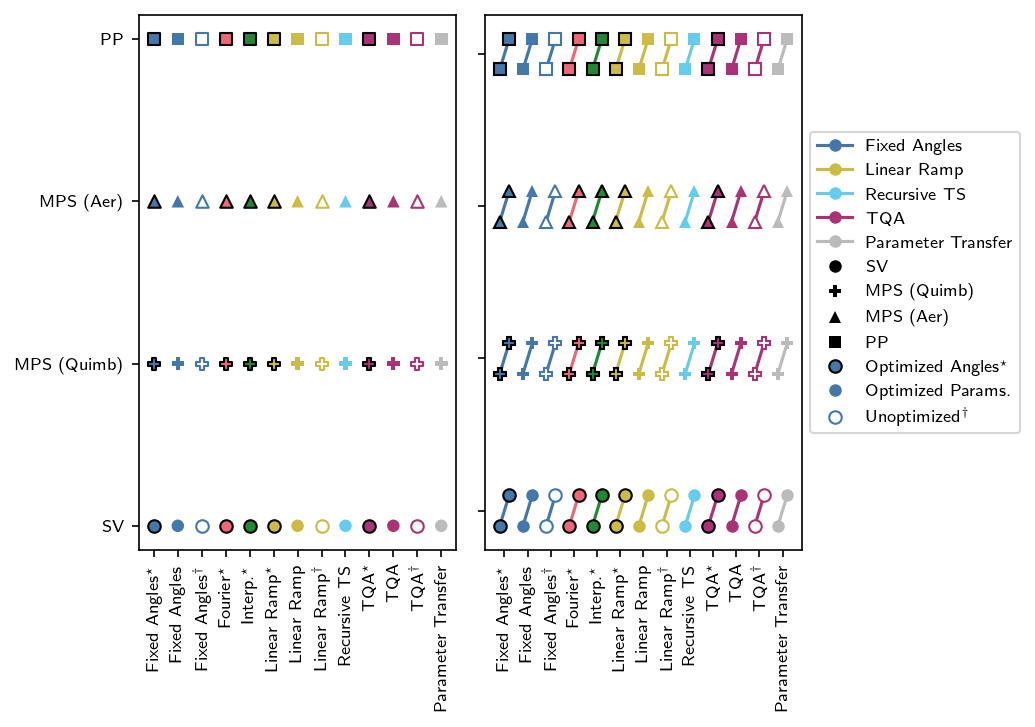

In [4]:

# Create figure with two subplots side by side
fig, axes = plt.subplots(1, 2, dpi=150, figsize=figsize(1 / 0.707, two_columns=True))
# Plot all combinations of methods and evaluations
for (i_method, method), (i_eval, evaluation) in product(
    enumerate(method_to_colour.keys()), enumerate(evaluation_markers.keys())
):
    # Left subplot: scatter plot
    axes[0].scatter(
        i_method,
        i_eval,
        **style_scatter(method=method, evaluation=evaluation),
    )
    # Right subplot: line plot
    axes[1].plot(
        [i_method - 0.2, i_method + 0.2],
        [i_eval - 0.1, i_eval + 0.1],
        **style_plot(method=method, evaluation=evaluation),
    )
# Configure axis labels and ticks for both subplots
for i_ax, ax in enumerate(axes):
    ax.set_xticks(
        range(len(method_to_colour)),
        labels=[
            format_method_label_to(method, format="latex")
            for method in method_to_colour.keys()
        ],
        rotation=90,
    )
    if i_ax == 0:
        ax.set_yticks(range(len(evaluation_markers)), labels=evaluation_markers.keys())
    else:
        ax.set_yticks(
            range(len(evaluation_markers)),
            labels=["" for _ in range(len(evaluation_markers))],
        )
# Build legend entries
legend_entries = []
# Add legend entries for each unique method (excluding duplicates with different markers)
for method in method_to_colour.keys():
    # Ignore methods which have multiple versions with different superscript markers
    if ("*" in method or "†" in method) and method not in [
        "Recursive TS",
        "Parameter Transfer",
    ]:
        continue
    legend_entries.append(
        (Line2D([], [], **style_plot(method=method, evaluation="SV")), method)
    )
# Add legend entries for each evaluation method marker
for evaluation in evaluation_markers.keys():
    legend_entries.append(
        (
            Line2D(
                [],
                [],
                linestyle=" ",
                color="k",
                **{
                    k: v
                    for k, v in style_plot(
                        method="Fixed Angles", evaluation=evaluation
                    ).items()
                    if k not in ["color", "linestyle", "markerfacecolor"]
                },
            ),
            evaluation,
        )
    )
# Add legend entries for optimization status indicators
for optimised_suffix, optimised_label in zip(
    ["*", "", "†"], ["Optimized Angles", "Optimized Params.", "Unoptimized"]
):
    legend_entries.append(
        (
            Line2D(
                [],
                [],
                linestyle=" ",
                **{
                    k: v
                    for k, v in style_plot(
                        method=f"Fixed Angles{optimised_suffix}", evaluation="SV"
                    ).items()
                    if k not in ["linestyle"]
                },
            ),
            format_method_label_to(optimised_label + optimised_suffix),
        )
    )
# Add legend to figure and adjust layout
axes[1].legend(
    *zip(*legend_entries), loc="center left", bbox_to_anchor=(1.0, 0.5, 0, 0)
)
plt.tight_layout()

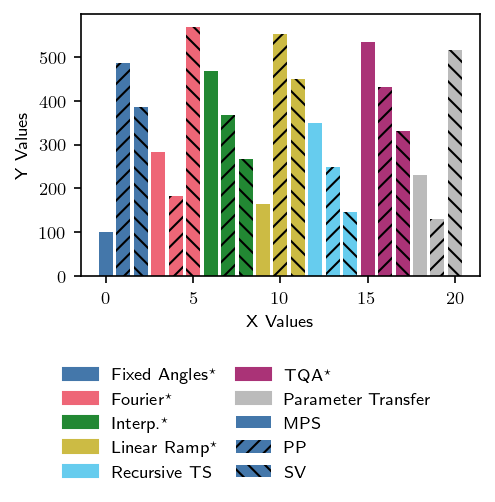

In [5]:
fig, ax = plt.subplots(1, 1, dpi=150, figsize=figsize(1 / 0.707))


def y(x: int) -> float:
    return (x * 7691) % 487 + 100


# Plot dummy data with correct styling.
methods = [
    "Fixed Angles*",
    "Fourier*",
    "Interp.*",
    "Linear Ramp*",
    "Recursive TS",
    "TQA*",
    "Parameter Transfer",
]
evaluations = ["MPS", "PP", "SV"]
hatch = {"MPS": None, "PP": "///", "SV": "\\\\\\"}
for x, (method, evaluation) in enumerate(
    product(
        methods,
        evaluations,
    )
):
    # We extract the colour from style_plot.
    style_kwargs = style_plot(evaluation="SV", method=method)
    ax.bar(
        x=x,
        height=y(x),
        hatch=hatch[evaluation],
        color=style_kwargs["color"],
    )

# Create legend with correct patch artists
legend_entries = []
for method in methods:
    legend_entries.append(
        (
            Patch(color=style_plot(evaluation="SV", method=method)["color"]),
            format_method_label_to(method),
        )
    )
for evaluation in evaluations:
    legend_entries.append(
        (
            Patch(
                # We need to use facecolor instead of color so we don't override edgecolor.
                facecolor=method_to_colour["Fixed Angles"],
                edgecolor="k",
                # linewidth removes the border, which is not present with
                # plt.bar(). The hatch linewidth is not set to 0.
                linewidth=0,
                hatch=hatch[evaluation],
            ),
            evaluation,
        )
    )
ax.set_xlabel("X Values")
ax.set_ylabel("Y Values")
fig.legend(
    *zip(*legend_entries),
    loc="upper center",
    bbox_to_anchor=(0.5, 0, 0, 0),
    frameon=False,
    ncol=2,
)
plt.tight_layout()
